In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = {
    "Email": [
        "Congratulations! You have won a free prize. Click now to claim.",
        "Win a brand new iPhone by entering this lucky draw.",
        "You have been selected for a cash reward. Claim your prize now.",
        "Get free money instantly. Click the link to receive your reward.",
        "Urgent! You have won $1000. Send your details to claim.",
        "Limited time offer! Get a free gift card today.",
        "Congratulations! You are the lucky winner of our lottery.",
        "Claim your free vacation package now. Offer expires today.",
        "You have won a free shopping voucher. Click here now.",
        "Exclusive offer! Get amazing rewards for free.",

        "Hi, can you send me the project report?",
        "Please find attached the meeting schedule for tomorrow.",
        "Can you let me know when the class will start?",
        "Thank you for sending the documents.",
        "Please submit your assignment before Friday.",
        "The meeting has been moved to 3 PM.",
        "Can we discuss the project tomorrow?",
        "Your order has been shipped and will arrive soon.",
        "Please confirm your appointment for Monday.",
        "I have attached the requested information."
    ],

    "Label": [
        "Spam", "Spam", "Spam", "Spam", "Spam",
        "Spam", "Spam", "Spam", "Spam", "Spam",
        "Ham", "Ham", "Ham", "Ham", "Ham",
        "Ham", "Ham", "Ham", "Ham", "Ham"
    ]
}

df = pd.DataFrame(data)

print(df)

                                                Email Label
0   Congratulations! You have won a free prize. Cl...  Spam
1   Win a brand new iPhone by entering this lucky ...  Spam
2   You have been selected for a cash reward. Clai...  Spam
3   Get free money instantly. Click the link to re...  Spam
4   Urgent! You have won $1000. Send your details ...  Spam
5     Limited time offer! Get a free gift card today.  Spam
6   Congratulations! You are the lucky winner of o...  Spam
7   Claim your free vacation package now. Offer ex...  Spam
8   You have won a free shopping voucher. Click he...  Spam
9      Exclusive offer! Get amazing rewards for free.  Spam
10            Hi, can you send me the project report?   Ham
11  Please find attached the meeting schedule for ...   Ham
12     Can you let me know when the class will start?   Ham
13               Thank you for sending the documents.   Ham
14       Please submit your assignment before Friday.   Ham
15                The meeting has been m

In [3]:
print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df["Label"].value_counts())

Dataset Shape: (20, 2)

Class Distribution:
Label
Spam    10
Ham     10
Name: count, dtype: int64


In [4]:
X = df["Email"]
y = df["Label"]

print("Emails:", len(X))
print("Labels:", len(y))

Emails: 20
Labels: 20


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Emails:", len(X_train))
print("Testing Emails:", len(X_test))

Training Emails: 16
Testing Emails: 4


In [6]:
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training data converted successfully!")
print("Training feature shape:", X_train_tfidf.shape)

Training data converted successfully!
Training feature shape: (16, 82)


In [7]:
model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [8]:
predictions = model.predict(X_test_tfidf)

print("Actual Labels:", list(y_test))
print("Predicted Labels:", list(predictions))

Actual Labels: ['Ham', 'Ham', 'Spam', 'Spam']
Predicted Labels: [np.str_('Ham'), np.str_('Ham'), np.str_('Spam'), np.str_('Spam')]


In [9]:
accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 1.0
Accuracy Percentage: 100.0 %


In [10]:
print("Classification Report:")
print(classification_report(y_test, predictions))

Classification Report:
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00         2
        Spam       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [11]:
new_email = ["Congratulations! You have won a free laptop. Click now to claim your prize."]

new_email_tfidf = vectorizer.transform(new_email)

prediction = model.predict(new_email_tfidf)

print("Email:", new_email[0])
print("Prediction:", prediction[0])

Email: Congratulations! You have won a free laptop. Click now to claim your prize.
Prediction: Spam


In [12]:
new_email = ["Please send me the project report before tomorrow's meeting."]

new_email_tfidf = vectorizer.transform(new_email)

prediction = model.predict(new_email_tfidf)

print("Email:", new_email[0])
print("Prediction:", prediction[0])

Email: Please send me the project report before tomorrow's meeting.
Prediction: Ham


In [13]:
new_emails = [
    "You have won a free cash prize. Click here to claim it.",
    "Please send me the assignment before the class.",
    "Congratulations! You are selected for a free gift.",
    "Can you please share the meeting details with me?",
    "Urgent! Claim your lottery reward now."
]

new_emails_tfidf = vectorizer.transform(new_emails)

predictions_new = model.predict(new_emails_tfidf)

for email, prediction in zip(new_emails, predictions_new):
    print("Email:", email)
    print("Prediction:", prediction)
    print("-" * 60)

Email: You have won a free cash prize. Click here to claim it.
Prediction: Spam
------------------------------------------------------------
Email: Please send me the assignment before the class.
Prediction: Ham
------------------------------------------------------------
Email: Congratulations! You are selected for a free gift.
Prediction: Spam
------------------------------------------------------------
Email: Can you please share the meeting details with me?
Prediction: Ham
------------------------------------------------------------
Email: Urgent! Claim your lottery reward now.
Prediction: Spam
------------------------------------------------------------


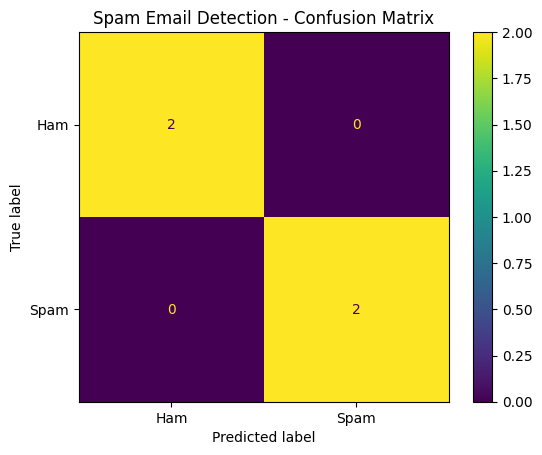

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, predictions)

plt.title("Spam Email Detection - Confusion Matrix")
plt.show()

In [15]:
feature_names = vectorizer.get_feature_names_out()
log_prob = model.feature_log_prob_[1]

top_indices = log_prob.argsort()[-10:][::-1]

print("Important words/features for Spam classification:")

for index in top_indices:
    print(feature_names[index])

Important words/features for Spam classification:
free
offer
now
get
won
claim
click
have
to
you


## Project Summary

This project uses Machine Learning and Natural Language Processing (NLP) to classify emails as Spam or Ham.

A TF-IDF vectorizer was used to convert email text into numerical features, and a Multinomial Naive Bayes model was trained for classification.

The model was evaluated using accuracy, classification report, and a confusion matrix. It was also tested on new email messages to verify its predictions.

### Key Findings

- The model successfully classified test emails into Spam and Ham categories.
- TF-IDF was used for text feature extraction.
- Multinomial Naive Bayes was used as the classification algorithm.
- The model was tested on new unseen email messages.
- Common words such as "free", "offer", "claim", and "prize" appeared as important features for Spam classification.

### Project Type

Machine Learning / Natural Language Processing (NLP)